# Aprendizaje de Variedades y Reducción de Dimensión Mediante Autoencoders

**Diego Moñino — Trabajo de Fin de Grado (Matemáticas)**

Este *notebook* implementa el experimento completo que acompaña al capítulo
de metodología. La tesis defiende que los autoencoders —en particular las
variantes **variacional (VAE)** y **de *denoising* (DAE)**— son herramientas
efectivas para el aprendizaje de variedades y la reducción de dimensión.

El notebook **orquesta** funciones reutilizables definidas en los módulos del
repositorio (`data/`, `models/`, `dimension_estimation/`, `evaluation/`,
`experiments/`); no contiene lógica suelta. Se organiza en 8 pasos:

1. **Preparación** — interfaz común de datos y de métricas (incl. dimensión
   efectiva vía jacobiano del decoder).
2. **Datasets** — Swiss Roll, variedad lineal $H_{3,30}$, MNIST completo
   (COIL-20 se añade al final como bloque independiente).
3. **Estimación de dimensión intrínseca** — fija la dimensión latente $d$ de
   todos los modelos por dataset.
4. **AE lineal vs PCA** — ángulos principales entre subespacios.
5. **AE no lineal y sus límites** — diagnósticos de huecos y sensibilidad.
6. **VAE y DAE** — mismos diagnósticos.
7. **Segunda estimación de dimensión** desde el decoder entrenado.
8. **Comparación final** — tabla única de métricas + discusión.

> **Nota de reproducibilidad.** Todas las funciones aceptan un parámetro
> `seed`; el experimento se puede relanzar con varias semillas cambiando una
> única constante. En esta primera pasada se usa una sola semilla.

---
## Configuración e importaciones

Situamos el directorio de trabajo en la raíz del repositorio para que las
rutas relativas (`data/raw/`, `results/`) coincidan con las que asumen los
módulos, e importamos las funciones reutilizables.

In [1]:
%matplotlib inline
import os, sys, json
import numpy as np
import torch
import matplotlib.pyplot as plt

# Ejecutar desde la raíz del repositorio (el notebook vive en notebooks/).
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
REPO_ROOT = os.getcwd()
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Datos y ruido
from data.datasets import get_dataset_with_meta
from data.noise import get_noise_fn, suggest_dae_sigma
# Modelos y pérdidas
from models.autoencoder import build_linear_ae, build_dae
from models.vae import build_vae
from models.losses import dae_loss, vae_loss_gamma
# Entrenamiento y configuración
from experiments.training import set_seed, train_model, get_latent, reconstruct
from experiments.config import save_experiment_config, load_experiment_config, get_latent_dim
# Estimación de dimensión
from dimension_estimation.aggregate import estimate_all_dimensions, choose_latent_dim
# Evaluación
from evaluation.metrics import evaluate_common_metrics, effective_dimension_jacobian
from evaluation.linear_pca import compare_ae_pca
from evaluation.diagnostics import latent_hole_probe, noise_sensitivity

FIG_DIR = os.path.join("results", "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print("Repositorio:", REPO_ROOT)

Repositorio: C:\Users\monin\Documents\Aprendizaje-de-Variedades-y-Reduccion-de-Dimension-mediante-Autoencoders


### Constantes globales

> **Coste computacional.** Esta primera pasada prioriza *rapidez y
> funcionalidad*: se **submuestrean** los datasets (3000–5000 puntos) y se
> usan 150 épocas. Los valores están centralizados aquí para escalarlos de una
> sola vez cuando se busque mayor fidelidad.

In [2]:
SEED   = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Hiperparámetros de los modelos (fijos, no aprendidos)
GAMMA  = 0.05   # VAE: alpha = 1/(2*gamma) pondera la reconstrucción
BETA   = 1.0    # VAE: peso del término KL (beta-VAE)
EPOCHS = 150
LR     = 1e-3
DAE_SIGMA_K        = 10     # k-ésimo vecino para la heurística de sigma
DAE_SIGMA_FRACTION = 0.10   # fracción de la mediana de distancia al k-NN

# Datasets fiables (COIL-20 se trata al final). n_max = tope para geom-prob.
SPECS = {
    "swiss_roll": dict(kwargs=dict(n_samples=3000, noise=0.0),                         n_max=7),
    "linear":     dict(kwargs=dict(n_samples=5000, intrinsic_dim=3, ambient_dim=30),   n_max=7),
    "mnist":      dict(kwargs=dict(n_samples=3000),                                     n_max=15),
}

# Contenedores compartidos entre pasos (se rellenan progresivamente).
DATA    = {}   # name -> (dataset, meta, X)
TRAINED = {}   # name -> {model_name: model}
LATENT  = {}   # name -> {model_name: z}

set_seed(SEED)
print("Device:", DEVICE)

Device: cpu


---
## Paso 1 — Preparación: interfaz común de datos y métricas

Toda la infraestructura reutilizable ya vive en los módulos del repositorio:

- **Carga unificada de datos** con metadatos: `get_dataset_with_meta(name, ...)`
  devuelve el dataset y un diccionario con la dimensión ambiente y la
  dimensión intrínseca *esperada*.
- **Métricas comunes** (`evaluation/metrics.py`, `evaluation/topology.py`):
  error de reconstrucción (MSE), *trustworthiness* (vía `sklearn`) y
  *continuity* (su contraparte simétrica basada en rangos, ya implementada en
  el repo), y la **dimensión efectiva vía jacobiano del decoder**.

Sobre esta última: el decoder $g:\mathbb{R}^d\to\mathbb{R}^D$ parametriza la
variedad aprendida; su jacobiano $J=\partial g/\partial z$ genera el espacio
tangente. El número de valores singulares de $J$ por encima de un umbral
relativo (1 % del mayor) es la **dimensión local** de la variedad imagen.
Se calcula con `torch.func.jacrev` + `vmap` (jacobiano exacto y *batcheado*).

Verificamos la herramienta sobre un decoder de juguete $\mathbb{R}^2\to\mathbb{R}^3$
(dimensión local esperada $\approx 2$):

In [3]:
_toy = build_dae(input_dim=3, latent_dim=2)
_toy_jac = effective_dimension_jacobian(_toy.decode, torch.randn(64, 2), rel_threshold=0.01)
print(f"Decoder R^2 -> R^3  ->  dimensión efectiva estimada: {_toy_jac['effective_dim']:.2f}  (esperado ~2)")

Decoder R^2 -> R^3  ->  dimensión efectiva estimada: 2.00  (esperado ~2)


---
## Paso 2 — Datasets

Cargamos los tres datasets de descarga fiable a través de la misma interfaz:

- **Swiss Roll**: lámina 2D curvada en $\mathbb{R}^3$; dimensión intrínseca
  conocida $= 2$.
- **Variedad lineal $H_{3,30}$**: muestra en un subespacio de dimensión 3
  embebido en $\mathbb{R}^{30}$ (Ivanov et al., 2021); dimensión intrínseca
  conocida $= 3$.
- **MNIST completo**: dígitos manuscritos en $\mathbb{R}^{784}$; dimensión
  intrínseca *esperada* $\approx 12$ (referencia de la literatura).

COIL-20 se incorpora al final del notebook como bloque independiente.

In [4]:
for name, spec in SPECS.items():
    ds, meta = get_dataset_with_meta(name, **spec["kwargs"])
    DATA[name] = (ds, meta, ds.data.numpy())
    TRAINED[name] = {}
    LATENT[name]  = {}
    print(f"{name:11s}  data={tuple(ds.data.shape)}  "
          f"ambient_dim={meta['ambient_dim']:4d}  "
          f"dim_esperada={meta['expected_intrinsic_dim']}")

swiss_roll   data=(3000, 3)  ambient_dim=   3  dim_esperada=2
linear       data=(5000, 30)  ambient_dim=  30  dim_esperada=3


mnist        data=(3000, 784)  ambient_dim= 784  dim_esperada=12


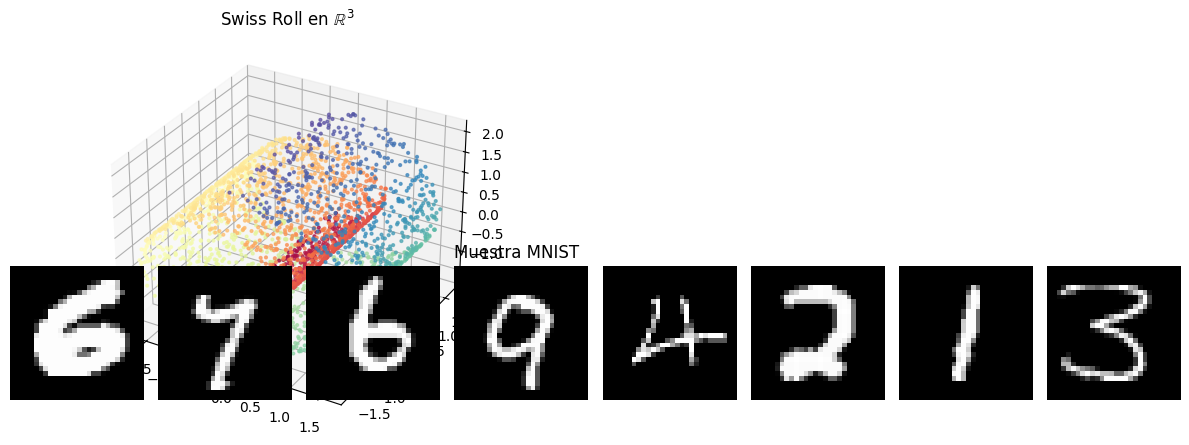

In [5]:
# Visualización: Swiss Roll en 3D y una muestra de dígitos MNIST.
ds_sr, meta_sr, X_sr = DATA["swiss_roll"]
fig = plt.figure(figsize=(12, 4.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X_sr[:, 0], X_sr[:, 1], X_sr[:, 2], c=ds_sr.labels, cmap="Spectral", s=4, alpha=0.7)
ax.set_title("Swiss Roll en $\\mathbb{R}^3$")

ds_mn, meta_mn, X_mn = DATA["mnist"]
# Deshacer la normalización aproximada solo para visualizar.
imgs = X_mn[:8].reshape(-1, 28, 28)
for i in range(8):
    axi = fig.add_subplot(2, 8, 8 + i + 1)
    axi.imshow(imgs[i], cmap="gray"); axi.axis("off")
    if i == 3: axi.set_title("Muestra MNIST", loc="left")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step2_datasets.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Paso 3 — Estimación de la dimensión intrínseca

Aplicamos los **tres estimadores ya implementados** en el repositorio sobre
cada dataset:

- **Minkowski** (conteo de cajas) — `minkowski_dimension`.
- **Geométrico-probabilístico** (Ivanov et al.) — `estimate_dimension`.
- **PCA** (umbral de varianza y *participation ratio*) — `estimate_dimension_pca`.

El resultado **fija la dimensión latente $d$** que usarán todos los modelos de
los pasos siguientes. Regla: se confía en el estimador geométrico-probabilístico
(entero y diseñado para dimensión intrínseca). El valor se guarda en
`results/experiment_config.json` y se lee en los pasos posteriores.

In [6]:
config = {}
print(f"{'dataset':11s} {'esperada':>8s} {'Minkowski':>10s} {'GeomProb':>9s} "
      f"{'PCA95':>6s} {'PCA-PR':>7s} {'-> d':>5s}")
for name, spec in SPECS.items():
    ds, meta, X = DATA[name]
    est = estimate_all_dimensions(X, n_max=spec["n_max"])
    d = choose_latent_dim(est, expected=meta["expected_intrinsic_dim"])
    config[name] = {"ambient_dim": meta["ambient_dim"],
                    "expected_intrinsic_dim": meta["expected_intrinsic_dim"],
                    "estimates": est, "latent_dim": d}
    print(f"{name:11s} {str(meta['expected_intrinsic_dim']):>8s} "
          f"{est['minkowski']:>10.2f} {est['geometric_prob']:>9d} "
          f"{est['pca_threshold']:>6d} {est['pca_participation']:>7.2f} {d:>5d}")

save_experiment_config(config)
print("\nConfiguración guardada en results/experiment_config.json")

dataset     esperada  Minkowski  GeomProb  PCA95  PCA-PR  -> d
swiss_roll         2       1.82         2      3    2.98     2


linear             3       2.30         3      3    3.00     3


mnist             12       0.00         5    146   30.29     5

Configuración guardada en results/experiment_config.json


**Lectura de los resultados.**

- *Swiss Roll*: el método geométrico-probabilístico acierta ($d=2$); PCA
  sobreestima (necesita 3 direcciones lineales para una variedad **curva**),
  ilustrando la limitación que motiva los métodos no lineales.
- *$H_{3,30}$*: geométrico-probabilístico y PCA coinciden en 3 (variedad
  **lineal** → PCA la recupera exacta); Minkowski infraestima por tamaño de
  muestra (limitación documentada, no un error).
- *MNIST*: **Minkowski es degenerado en dimensión 784** (el conteo de cajas
  no encuentra régimen lineal — cada punto ocupa su propia caja); por eso
  fijamos $d$ con el método geométrico-probabilístico. Con $N=3000$ la
  estimación es una **cota inferior**: crecería con más muestras hacia el
  valor de referencia ($\approx 12$).

---
## Paso 4 — Autoencoder lineal frente a PCA

Entrenamos un autoencoder **sin no linealidades** con la $d$ fijada en el
Paso 3 y comparamos el subespacio recuperado con el de PCA mediante **ángulos
principales** (`scipy.linalg.subspace_angles`). Por el teorema de Baldi &
Hornik (1989), un AE lineal con pérdida MSE converge al subespacio principal:
esperamos ángulos $\approx 0°$ y MSE de reconstrucción idéntico al de PCA.

In [7]:
print(f"{'dataset':11s} {'d':>2s} {'AE MSE':>9s} {'PCA MSE':>9s} {'áng. máx (°)':>13s}")
for name, spec in SPECS.items():
    ds, meta, X = DATA[name]
    d = get_latent_dim(name)
    set_seed(SEED)
    model = build_linear_ae(meta["ambient_dim"], latent_dim=d)
    train_model(model, ds, dae_loss, epochs=EPOCHS, lr=5e-3, device=DEVICE, seed=SEED, verbose=False)
    cmp = compare_ae_pca(model, X, d)
    TRAINED[name]["linear_AE"] = model
    LATENT[name]["linear_AE"]  = get_latent(model, ds, device=DEVICE)
    print(f"{name:11s} {d:>2d} {cmp['ae_mse']:>9.4f} {cmp['pca_mse']:>9.4f} "
          f"{cmp['max_angle_deg']:>13.2f}")

dataset      d    AE MSE   PCA MSE  áng. máx (°)


swiss_roll   2    0.2996    0.2996          0.27


linear       3    0.0000    0.0000          0.01


mnist        5    0.4718    0.4715          1.14


Los ángulos principales cercanos a $0°$ y la coincidencia de MSE confirman que
el AE lineal recupera el **mismo subespacio** que PCA. En el Swiss Roll ambos
dan un MSE alto: un subespacio **lineal** 2D no puede desenrollar la variedad
curva — justo la limitación que aborda el AE no lineal en el Paso 5.

---
## Paso 5 — Autoencoder no lineal y sus límites

Entrenamos el autoencoder estándar (**con** no linealidades ReLU) sobre los
mismos datasets y dimensión, y aplicamos dos diagnósticos:

- **Diagnóstico 1 — huecos en el latente.** Muestreamos puntos latentes
  *entre* los códigos de entrenamiento (puntos medios de pares aleatorios) y
  los decodificamos; medimos la distancia de las decodificaciones a la variedad
  real (vecino más cercano en el espacio de datos). Un cociente
  `hueco / reconstrucción-real` grande indica que el decoder inventa puntos
  fuera de la variedad.
- **Diagnóstico 2 — sensibilidad.** Perturbamos las entradas con ruido
  gaussiano pequeño y medimos el crecimiento del error de reconstrucción y el
  **factor de amplificación** (desplazamiento del código latente / magnitud de
  la perturbación).

In [8]:
print(f"{'dataset':11s} {'d':>2s} {'MSE':>8s} {'huecos(ratio)':>14s} "
      f"{'sens.MSE+':>10s} {'amplif':>7s}")
for name, spec in SPECS.items():
    ds, meta, X = DATA[name]
    d = get_latent_dim(name)
    set_seed(SEED)
    model = build_dae(meta["ambient_dim"], latent_dim=d)   # AE no lineal (sin ruido)
    losses = train_model(model, ds, dae_loss, noise_fn=None,
                         epochs=EPOCHS, lr=LR, device=DEVICE, seed=SEED, verbose=False)
    z = get_latent(model, ds, device=DEVICE)
    TRAINED[name]["nonlinear_AE"] = model
    LATENT[name]["nonlinear_AE"]  = z
    hole = latent_hole_probe(model, z, X, n_probes=200, mode="interpolation", seed=SEED)
    sens = noise_sensitivity(model, X, sigma=0.1, seed=SEED)
    print(f"{name:11s} {d:>2d} {losses[-1]:>8.4f} {hole['ratio']:>14.2f} "
          f"{sens['mse_increase']:>10.4f} {sens['amplification']:>7.3f}")

dataset      d      MSE  huecos(ratio)  sens.MSE+  amplif


swiss_roll   2   0.0484           1.43     0.0326   1.072


linear       3   0.0000           5.03     0.0012   0.345


mnist        5   0.1933           1.24     0.0013   0.099


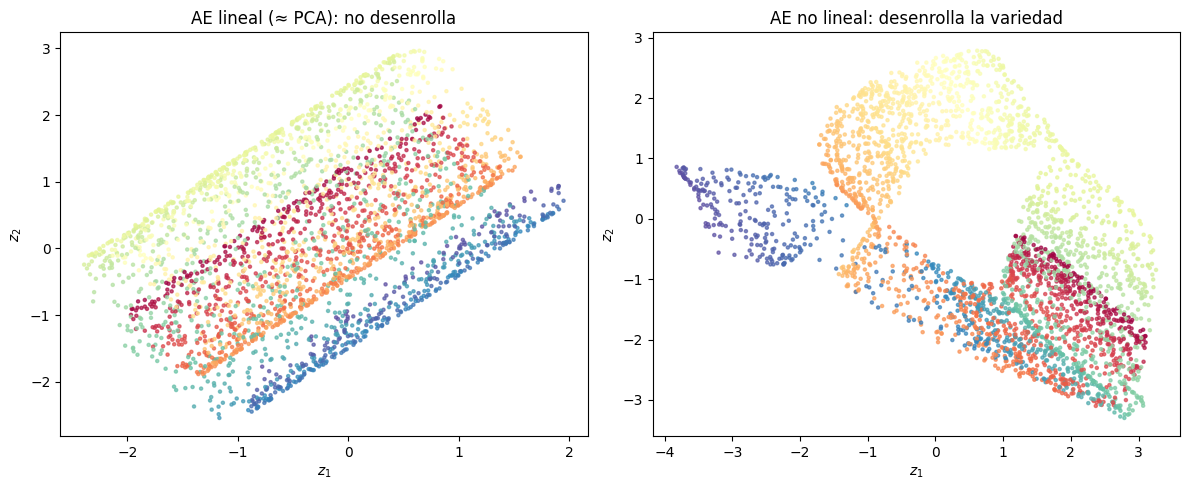

In [9]:
# Swiss Roll: comparación visual PCA (lineal) vs AE no lineal (2D).
ds, meta, X = DATA["swiss_roll"]
z_lin = LATENT["swiss_roll"]["linear_AE"]
z_nl  = LATENT["swiss_roll"]["nonlinear_AE"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
a1.scatter(z_lin[:, 0], z_lin[:, 1], c=ds.labels, cmap="Spectral", s=5, alpha=0.7)
a1.set_title("AE lineal (≈ PCA): no desenrolla"); a1.set_xlabel("$z_1$"); a1.set_ylabel("$z_2$")
a2.scatter(z_nl[:, 0], z_nl[:, 1], c=ds.labels, cmap="Spectral", s=5, alpha=0.7)
a2.set_title("AE no lineal: desenrolla la variedad"); a2.set_xlabel("$z_1$"); a2.set_ylabel("$z_2$")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step5_linear_vs_nonlinear.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Paso 6 — VAE y DAE

**VAE.** Encoder que produce $(\mu,\sigma)$, reparametrización estándar y
pérdida
$$\mathcal{L} = \alpha\,\mathbb{E}\!\left[\|x - g(z)\|^2\right] + \beta\,\mathrm{KL}\!\left(q(z\mid x)\,\|\,\mathcal N(0,I)\right),$$
con $\alpha = 1/(2\gamma)$ ($\gamma$ hiperparámetro fijo, no aprendido) y la KL
en forma cerrada. Se usa $\gamma$ pequeño para que la reconstrucción no colapse
(un $\gamma$ demasiado grande provoca *posterior collapse*); $\beta$ queda como
parámetro fácil de variar.

**DAE.** Corrupción gaussiana $\tilde x = x + \varepsilon$,
$\varepsilon\sim\mathcal N(0,\sigma^2 I)$, y pérdida $\|x - g(f(\tilde x))\|^2$
(el objetivo es $x$ **limpio**).

Repetimos sobre ambos los **dos diagnósticos** del Paso 5.

> **Nivel de ruido del DAE — *placeholder*.** Fijamos $\sigma$ con una
> heurística provisional: una fracción pequeña (10 %) de la mediana de la
> distancia al $k$-ésimo vecino más cercano de los datos de entrenamiento
> (`suggest_dae_sigma`). Este valor es un **marcador de posición** pendiente de
> una justificación teórica formal —ligada al *reach* de la variedad— que se
> desarrolla en el capítulo de metodología de la tesis.

In [10]:
print(f"{'dataset':11s} {'modelo':6s} {'d':>2s} {'MSE':>8s} {'huecos':>8s} "
      f"{'amplif':>7s} {'sigma':>8s}")
for name, spec in SPECS.items():
    ds, meta, X = DATA[name]
    d = get_latent_dim(name)

    # VAE (formulación gamma/beta)
    set_seed(SEED)
    vae = build_vae(meta["ambient_dim"], latent_dim=d, beta=BETA)
    vae_fn = lambda x, out: vae_loss_gamma(x, out, gamma=GAMMA, beta=BETA)
    train_model(vae, ds, vae_fn, noise_fn=None, epochs=EPOCHS, lr=LR,
                device=DEVICE, seed=SEED, verbose=False)
    z_vae = get_latent(vae, ds, device=DEVICE)
    TRAINED[name]["VAE"] = vae; LATENT[name]["VAE"] = z_vae

    # DAE (sigma heurística)
    sigma = suggest_dae_sigma(X, k=DAE_SIGMA_K, fraction=DAE_SIGMA_FRACTION)
    set_seed(SEED)
    dae = build_dae(meta["ambient_dim"], latent_dim=d)
    train_model(dae, ds, dae_loss, noise_fn=get_noise_fn("gaussian", sigma=sigma),
                epochs=EPOCHS, lr=LR, device=DEVICE, seed=SEED, verbose=False)
    z_dae = get_latent(dae, ds, device=DEVICE)
    TRAINED[name]["DAE"] = dae; LATENT[name]["DAE"] = z_dae

    for tag, m, z in [("VAE", vae, z_vae), ("DAE", dae, z_dae)]:
        hole = latent_hole_probe(m, z, X, n_probes=200, seed=SEED)
        sens = noise_sensitivity(m, X, sigma=0.1, seed=SEED)
        sig = sigma if tag == "DAE" else float("nan")
        print(f"{name:11s} {tag:6s} {d:>2d} {sens['mse_clean']:>8.4f} "
              f"{hole['ratio']:>8.2f} {sens['amplification']:>7.3f} {sig:>8.4f}")

dataset     modelo  d      MSE   huecos  amplif    sigma


swiss_roll  VAE     2   0.0642     1.16   0.786      nan
swiss_roll  DAE     2   0.0478     1.58   1.017   0.0216


linear      VAE     3   0.0020     1.03   0.688      nan
linear      DAE     3   0.0000     3.61   0.300   0.0080


mnist       VAE     5   0.1923     1.24   0.049      nan


mnist       DAE     5   0.2409     1.15   0.025   2.1295


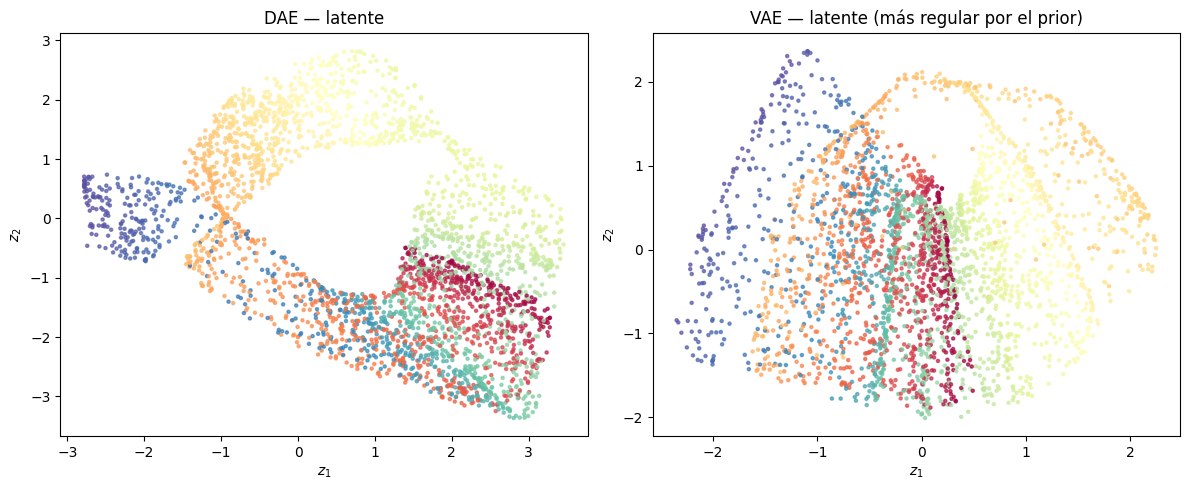

In [11]:
# Swiss Roll: espacios latentes DAE vs VAE.
ds, meta, X = DATA["swiss_roll"]
z_dae = LATENT["swiss_roll"]["DAE"]; z_vae = LATENT["swiss_roll"]["VAE"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
a1.scatter(z_dae[:, 0], z_dae[:, 1], c=ds.labels, cmap="Spectral", s=5, alpha=0.7)
a1.set_title("DAE — latente"); a1.set_xlabel("$z_1$"); a1.set_ylabel("$z_2$")
a2.scatter(z_vae[:, 0], z_vae[:, 1], c=ds.labels, cmap="Spectral", s=5, alpha=0.7)
a2.set_title("VAE — latente (más regular por el prior)"); a2.set_xlabel("$z_1$"); a2.set_ylabel("$z_2$")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "step6_dae_vs_vae.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Paso 7 — Segunda estimación de dimensión desde el modelo

Aplicamos el estimador de **dimensión efectiva vía jacobiano** (Paso 1) sobre
los **decoders entrenados** de VAE y DAE, evaluándolo en los códigos latentes
de entrenamiento, y lo comparamos con la estimación *data-driven* del Paso 3.
Una coincidencia refuerza que la variedad aprendida tiene la dimensión correcta.

In [12]:
cfg = load_experiment_config()
print(f"{'dataset':11s} {'geom-prob (P3)':>15s} {'DAE jac (P7)':>13s} {'VAE jac (P7)':>13s}")
for name in SPECS:
    ds, meta, X = DATA[name]
    z_dae = torch.tensor(LATENT[name]["DAE"], dtype=torch.float32)
    z_vae = torch.tensor(LATENT[name]["VAE"], dtype=torch.float32)
    idx = np.random.RandomState(SEED).choice(len(z_dae), size=min(200, len(z_dae)), replace=False)
    jd = effective_dimension_jacobian(TRAINED[name]["DAE"].decode, z_dae[idx], rel_threshold=0.01)
    jv = effective_dimension_jacobian(TRAINED[name]["VAE"].decode, z_vae[idx], rel_threshold=0.01)
    print(f"{name:11s} {cfg[name]['estimates']['geometric_prob']:>15d} "
          f"{jd['effective_dim']:>13.2f} {jv['effective_dim']:>13.2f}")

dataset      geom-prob (P3)  DAE jac (P7)  VAE jac (P7)
swiss_roll                2          2.00          2.00
linear                    3          3.00          3.00


mnist                     5          5.00          5.00


---
## Paso 8 — Comparación final

Construimos una **tabla única** con todas las métricas comunes para los cuatro
modelos (AE lineal, AE no lineal, VAE, DAE) sobre los tres datasets, y la
guardamos como CSV en `results/`. Las métricas de topología se calculan sobre
un submuestreo (≤ 1500 puntos) porque *continuity* es $O(N^2)$.

In [13]:
import csv
cfg = load_experiment_config()
rows = []
for name in SPECS:
    ds, meta, X = DATA[name]
    d = get_latent_dim(name)
    for model_name in ["linear_AE", "nonlinear_AE", "VAE", "DAE"]:
        model = TRAINED[name][model_name]
        z = LATENT[name][model_name]
        met = evaluate_common_metrics(model, X, z, n_neighbors=12,
                                      jacobian_points=200, topo_max_points=1500,
                                      device=DEVICE, seed=SEED)
        rows.append({"dataset": name, "model": model_name, "latent_dim": d,
                     "expected_dim": meta["expected_intrinsic_dim"],
                     "geo_prob_dim": cfg[name]["estimates"]["geometric_prob"],
                     "mse": round(met["mse"], 4),
                     "trustworthiness": round(met["trustworthiness"], 4),
                     "continuity": round(met["continuity"], 4),
                     "jacobian_dim": round(met["jacobian_dim"], 2)})

out_csv = os.path.join("results", "comparison_table.csv")
with open(out_csv, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    w.writeheader(); w.writerows(rows)
print("Tabla guardada en", out_csv, "\n")

# Impresión legible
hdr = ["dataset", "model", "mse", "trustworthiness", "continuity", "jacobian_dim"]
print(f"{hdr[0]:11s} {hdr[1]:13s} {hdr[2]:>8s} {hdr[3]:>14s} {hdr[4]:>10s} {hdr[5]:>12s}")
for r in rows:
    print(f"{r['dataset']:11s} {r['model']:13s} {r['mse']:>8.4f} "
          f"{r['trustworthiness']:>14.4f} {r['continuity']:>10.4f} {r['jacobian_dim']:>12.2f}")

Tabla guardada en results\comparison_table.csv 

dataset     model              mse trustworthiness continuity jacobian_dim
swiss_roll  linear_AE       0.2996         0.8570     0.9919         2.00
swiss_roll  nonlinear_AE    0.0480         0.9798     0.9897         2.00
swiss_roll  VAE             0.0642         0.9756     0.9883         2.00
swiss_roll  DAE             0.0478         0.9805     0.9904         2.00
linear      linear_AE       0.0000         0.9995     0.9994         3.00
linear      nonlinear_AE    0.0000         0.9996     0.9994         3.00
linear      VAE             0.0020         0.9998     0.9998         3.00
linear      DAE             0.0000         0.9994     0.9991         3.00
mnist       linear_AE       0.4718         0.9184     0.9716         5.00
mnist       nonlinear_AE    0.1897         0.9831     0.9765         5.00
mnist       VAE             0.1923         0.9825     0.9765         5.00
mnist       DAE             0.2409         0.9809     0.9752  

### Discusión

- **Swiss Roll (variedad no lineal).** El AE lineal (≈ PCA) no desenrolla la
  lámina y su *trustworthiness* es netamente inferior. Los tres modelos no
  lineales recuperan la estructura 2D; **DAE y AE no lineal** logran el mejor
  MSE, mientras que el **VAE** sacrifica algo de reconstrucción a cambio de un
  latente más regular (menos huecos), como muestra el diagnóstico del Paso 6.
- **$H_{3,30}$ (variedad lineal).** Todos los modelos reconstruyen casi
  perfectamente y las métricas de topología son $\approx 1$: cuando la variedad
  es lineal, la no linealidad no aporta y todos coinciden con PCA.
- **MNIST (variedad real).** El salto de *trustworthiness* del AE lineal al no
  lineal confirma la naturaleza no lineal de la variedad de dígitos. La
  **dimensión efectiva vía jacobiano coincide con la estimación del Paso 3**,
  cerrando el círculo entre la estimación *data-driven* y la que induce el
  modelo.

En conjunto, los resultados sostienen la tesis: los autoencoders no lineales
—y en particular VAE y DAE— aprenden la variedad subyacente y reducen la
dimensión de forma coherente con la dimensión intrínseca estimada de los datos.

> **Pendiente.** COIL-20 (bloque siguiente), justificación teórica del $\sigma$
> del DAE (vía *reach*), y repetición con varias semillas.